# Developing CNN model to classify insurance claims based on vehicle damage images. 

In [38]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, Dense, Dropout, GlobalAveragePooling2D, MaxPooling2D, Flatten, Rescaling, RandomFlip, RandomRotation, RandomZoom, BatchNormalization
from tensorflow.keras.applications import MobileNetV2

In [39]:
base_dir = "accident_pics/train/train"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

In [40]:
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed()

In [41]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "accident_pics/train/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "accident_pics/train/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 7200 files belonging to 6 classes.
Using 5760 files for training.
Found 7200 files belonging to 6 classes.
Using 1440 files for validation.


In [5]:
train_ds.class_names

['crack', 'dent', 'glass shatter', 'lamp broken', 'scratch', 'tire flat']

In [42]:
labels = {
    0: 'crack',
    1: 'scratch',
    2: 'tire flat',
    3: 'dent',
    4: 'glass shatter',
    5: 'lamp broken'
}

In [43]:
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [44]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])


In [9]:
model = Sequential([
    Input(shape=(224, 224, 3)),
    
    Rescaling(1./255),
    data_augmentation,

    Conv2D(32, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(6, activation="softmax")
])


In [10]:
model.summary() 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,813,766 (25.99 MB)

 Trainable params: 6,812,806 (25.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)


In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 366s 1s/step - accuracy: 0.3785 - loss: 1.6059 - val_accuracy: 0.3313 - val_loss: 2.8371
Epoch 2/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 352s 978ms/step - accuracy: 0.4420 - loss: 1.3451 - val_accuracy: 0.5083 - val_loss: 1.1890
Epoch 3/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 348s 968ms/step - accuracy: 0.4510 - loss: 1.2743 - val_accuracy: 0.4986 - val_loss: 1.1779
Epoch 4/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 355s 986ms/step - accuracy: 0.4870 - loss: 1.2102 - val_accuracy: 0.5181 - val_loss: 1.1441
Epoch 5/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 357s 992ms/step - accuracy: 0.4950 - loss: 1.1841 - val_accuracy: 0.5347 - val_loss: 1.1000
Epoch 6/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 345s 958ms/step - accuracy: 0.5175 - loss: 1.1386 - val_accuracy: 0.5090 - val_loss: 1.2813
Epoch 7/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 339s 942ms/step - accuracy: 0.5142 - loss: 1.1475 - val_accuracy: 0.5674 - val_loss: 1.0555
Epoch 8/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 344s 955ms/step - accuracy: 0.5229 - lo

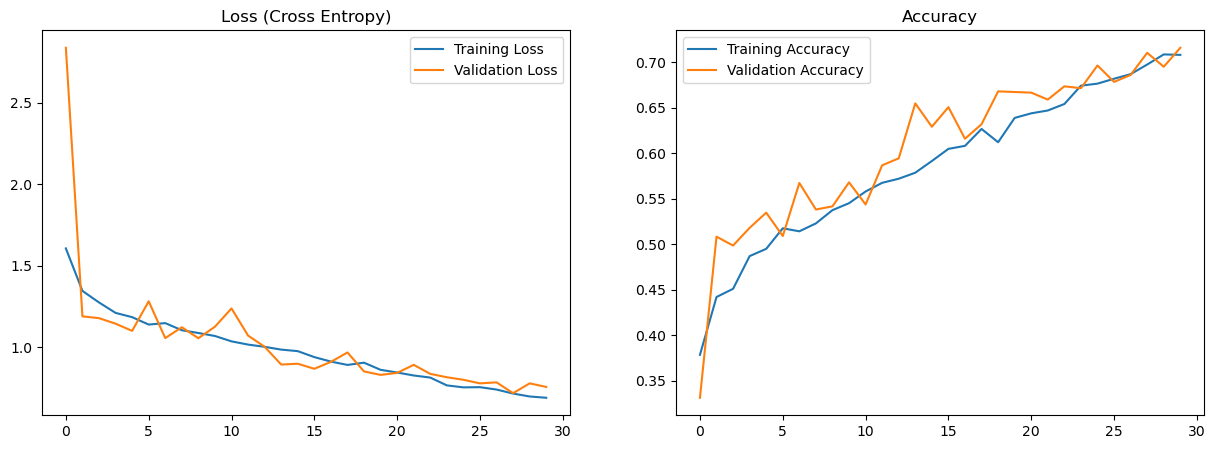

In [16]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))


ax[0].plot(history_df['loss'], label='Training Loss')
ax[0].plot(history_df['val_loss'], label='Validation Loss')
ax[0].set_title('Loss (Cross Entropy)')
ax[0].legend()

\
ax[1].plot(history_df['accuracy'], label='Training Accuracy')
ax[1].plot(history_df['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Accuracy')
ax[1].legend()

plt.show()


In [46]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
])

preprocess_input = mobilenet_v2.preprocess_input


In [50]:
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False, 
                         weights='imagenet')

base_model.trainable = False 

inputs = Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(6, activation='softmax')(x)

model_tl = tf.keras.Model(inputs, outputs)


model_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])


history_t1 = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 175s 469ms/step - accuracy: 0.5627 - loss: 1.1272 - val_accuracy: 0.6785 - val_loss: 0.8365
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 135s 376ms/step - accuracy: 0.6986 - loss: 0.7826 - val_accuracy: 0.7090 - val_loss: 0.7426
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 139s 387ms/step - accuracy: 0.7378 - loss: 0.6889 - val_accuracy: 0.7368 - val_loss: 0.6802
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 141s 392ms/step - accuracy: 0.7679 - loss: 0.6220 - val_accuracy: 0.7465 - val_loss: 0.6389
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 140s 388ms/step - accuracy: 0.7795 - loss: 0.5782 - val_accuracy: 0.7632 - val_loss: 0.6047
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 142s 393ms/step - accuracy: 0.7934 - loss: 0.5317 - val_accuracy: 0.7701 - val_loss: 0.5831
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 139s 387ms/step - accuracy: 0.8104 - loss: 0.4929 - val_accuracy: 0.7708 - val_loss: 0.5674
Epoch 8/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 140s 390ms/step - accuracy: 0.8314 -

In [59]:
type(history_t1)

keras.src.callbacks.history.History

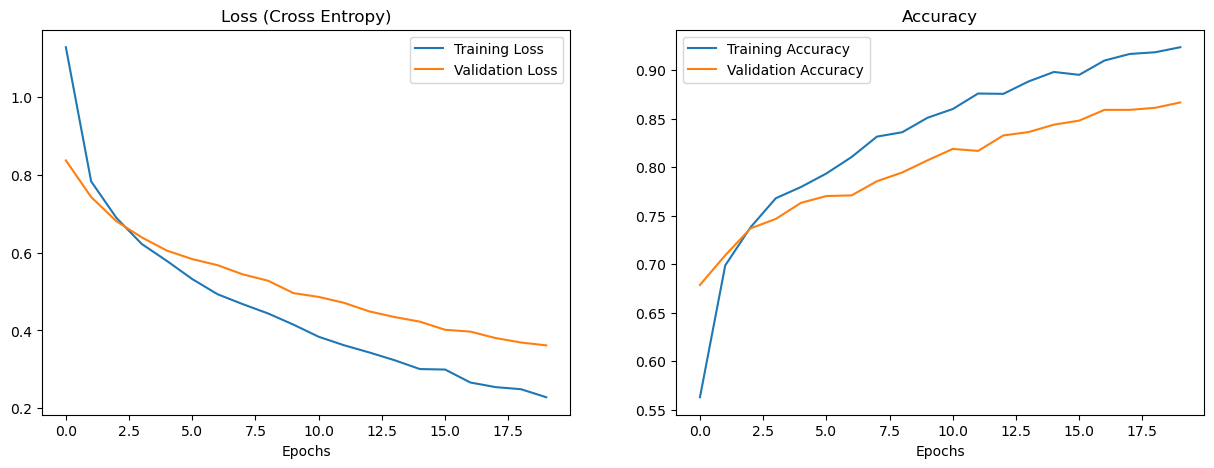

In [60]:
history_df1 = pd.DataFrame(history_t1.history)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))


ax[0].plot(history_df1['loss'], label='Training Loss')
ax[0].plot(history_df1['val_loss'], label='Validation Loss')
ax[0].set_title('Loss (Cross Entropy)')
ax[0].legend()
ax[0].set_xlabel('Epochs')

ax[1].plot(history_df1['accuracy'], label='Training Accuracy')
ax[1].plot(history_df1['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("transfer_learning_history.png")
plt.show()

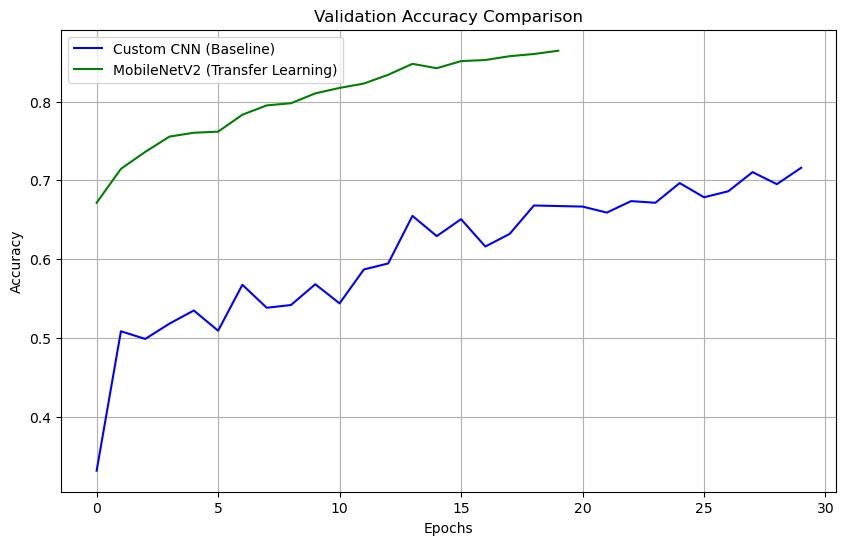

In [26]:

plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Custom CNN (Baseline)', color='blue')
plt.plot(history_t1.history['val_accuracy'], label='MobileNetV2 (Transfer Learning)', color='green')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()